In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data/nutrient_deficiency_text_dataset_2100.csv")
df.sample(3)

,nutrient_deficiency,symptoms,recommended_foods,recommended_beverages
443,Calcium,"bone pain, tooth decay, osteoporosis risk, mus...","sardines, yogurt, milk",milk
879,Iron,"headache, pale skin","tofu, spinach",pomegranate juice
1708,Zinc,"diarrhea, reduced immunity, loss of taste, hai...","nuts, shellfish",nut milk


<Axes: xlabel='count', ylabel='nutrient_deficiency'>

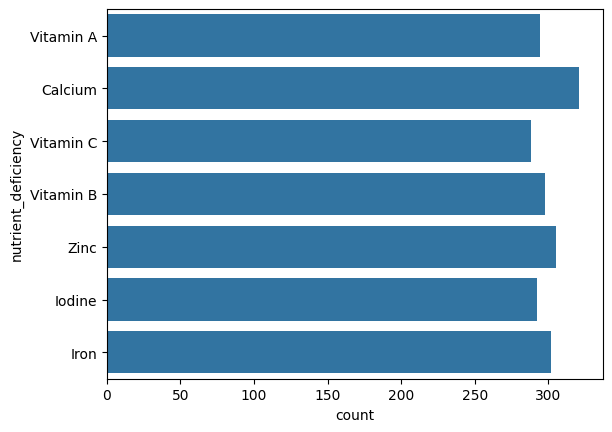

In [ ]:
sns.countplot(df['nutrient_deficiency'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   nutrient_deficiency    2100 non-null   object
 1   symptoms               2100 non-null   object
 2   recommended_foods      2100 non-null   object
 3   recommended_beverages  2100 non-null   object
dtypes: object(4)
memory usage: 65.8+ KB


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = df["symptoms"]
y = df["nutrient_deficiency"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline
text_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

text_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000))])

In [ ]:
symptoms = "diarrhea, loss of taste, skin rash, reduced immunity"

In [ ]:
predicted_deficiency = text_model.predict([symptoms])[0]
print("Predicted Nutrient Deficiency:", predicted_deficiency)

Predicted Nutrient Deficiency: Zinc


In [ ]:
import pickle

with open("text_model.pkl", "wb") as file:
  pickle.dump(text_model, file)